# Select in focus z through time

When acquiring BF images the embryo can shift in z the field of view, so a 3D stack is acquired through time. It is often useful to select a single plane from this stack **in focus** for further analysis. To reduce the amount of data to be processed.


In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from scipy.ndimage import laplace


In [9]:
data_folder = "../data/stack_images/"
output_folder = "../data/stack_images/output/"

image_paths = glob.glob(os.path.join(data_folder, "*.tiff"))

# check the first image
img = tifffile.imread(image_paths[0])
print("First image shape: {}".format(img.shape))

# dimension order of the image
dimension_order = "tzyx"

print("Found {} images".format(len(image_paths)))
print("Dimension order: {}".format(dimension_order))

First image shape: (287, 2, 1073, 1064)
Found 1 images
Dimension order: tzyx


In [3]:
def transpose_to_ome_order(img, input_order):
    """
    Transpose the image to the OME order
    """
    ome_zarr_dimension_order = "tzcyx" # DO NOT CHANGE THIS

    # if all dimension are not present, add them at the end
    if len(input_order) < len(ome_zarr_dimension_order):
        # get the dimensions that are not present
        not_present_dim = [d for d in ome_zarr_dimension_order if d not in input_order]
        input_order += "".join(not_present_dim)
        # add a dummy dimension at the end
        for _ in not_present_dim:
            img = np.expand_dims(img, axis=-1)

    order = [input_order.index(d) for d in ome_zarr_dimension_order]
    return img.transpose(order)

# plot the scores
def plot_scores(scores):
    scores = np.array(scores)
    plt.figure()
    plt.plot(scores[:,0])
    plt.plot(scores[:,1])
    plt.legend([f"z={z}" for z in range(scores.shape[-1])])
    plt.xlabel("time")
    plt.ylabel("laplacian variance")
    plt.show()

../data/stack_images/2024-01-17-Natural_Lumen_growth_Ctl_mtmg_ZP_noZP_E2_5_10min_CellDisc_20Xx2_-01-Scene-1-Control_noZP-3_s1.ome.tiff
Image shape: (287, 2, 1073, 1064)


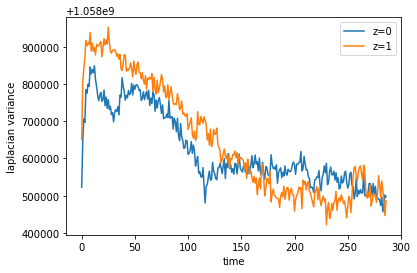

Output image shape: (287, 1064, 1073)
Saved to ../data/stack_images/output/2024-01-17-Natural_Lumen_growth_Ctl_mtmg_ZP_noZP_E2_5_10min_CellDisc_20Xx2_-01-Scene-1-Control_noZP-3_s1.ome.tiff


In [7]:
for image_path in image_paths:
    print(image_path)

    # open image and normalize the dimensions order
    img = tifffile.imread(image_path)
    print("Image shape: {}".format(img.shape))
    ome_img = transpose_to_ome_order(img, dimension_order)
    scores = []

    # select the best z plane for each time point
    new_img = []
    for t in range(ome_img.shape[0]):
        temp = []
        time_point = ome_img[t]
        for z in range(ome_img.shape[1]):
            img_z = time_point[z]
            score = np.var(laplace(img_z))
            temp.append(score)
        scores.append(temp)
        new_img.append(time_point[np.argmin(temp)])
    plot_scores(scores)

    # save the image
    new_img = np.squeeze(new_img)
    print("Output image shape: {}".format(new_img.shape))
    new_path = os.path.join(output_folder, os.path.basename(image_path))
    tifffile.imwrite(new_path, new_img)
    print("Saved to {}".format(new_path))